In [1]:
#url = 'https://raw.githubusercontent.com/flavianowilliams/Notebooks/master/M3L/argon/Ar_94K_1atm.json'
#from urllib.request import urlopen
#file = urlopen(url)
#with open('Ar_94K_1atm.json','wb') as output:
#  output.write(file.read())
#
# carregando sistema físico
from m3l.structure import System as sys
import json
#
system = sys()
system.loadSystem('Ar_94K.json')
#
# convertendo as unidades de medida
system.convertUnits()

In [2]:
# definindo o modelo de interação entre os átomos (campo de força)      
import m3l.force_field as ff
from m3l.force_field import Intermolecular as interff
from m3l.force_field import Molecules as mo
class Forces(ff.ForceField):
    def __init__(self):
        super().__init__()
        self.van_der_waals = self.sites(
            interff.site(1, 1, 0.2385, 3.4), #site ID, atomic charge, Lennard-Jones parameters
        )
        self.electrostatic = 'coulomb'
        self.convertUnits()
#        
model = Forces()
model()

(1, 0.0, 0.0, [[[1, 1]], [[0.0003802000129863748, 6.42506882808646]]])

In [3]:
# Definindo método de otimização
from m3l.optimize import Optimize as optim
#
opt = optim(model(), learning_rate = 1.e-2)

In [4]:
# executando looping
import time
import csv
#
n_steps = 1000
start = time.time()
with open('optimize.csv', 'w', newline = '') as csvfile:
    fieldnames = ['step', 'energy']
    writer = csv.DictWriter(csvfile, fieldnames = fieldnames)
    writer.writeheader()
    for step in range(1, n_steps+1):
        system = opt(system)
        writer.writerow({
            'step': step,
            'energy': system.epotential/system.ECONV})
#
end = time.time()
print(f'Elapsed time: {end - start}')

Elapsed time: 5.933698654174805


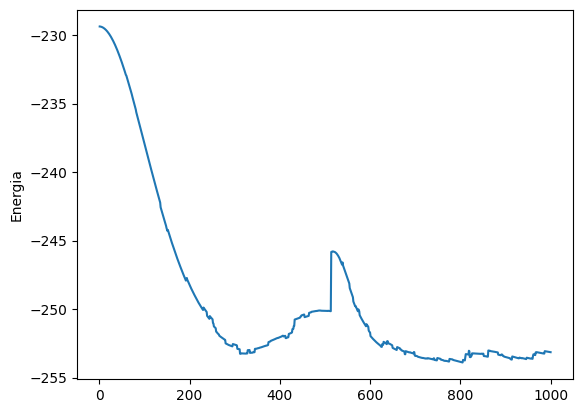

In [5]:
import matplotlib.pyplot as plt
import numpy as np
dataset = np.loadtxt("optimize.csv", dtype=np.float32, delimiter = ",", skiprows=1)
x_list = [item[0].item() for item in dataset]
y_list = [item[1].item() for item in dataset]
plt.plot(x_list, y_list)
plt.ylabel('Energia')
#plt.ylim(0,1e28)
plt.show()

In [6]:
system.convertUnitsInv()
#system.save('system_Ar_300_opt.json')